### Using the HadISD datset (version 3.4.0.2023f) with PyEarthTools
HadISD is a global sub-daily dataset based on the ISD dataset from NOAA's NCEI. As well as station selection criteria, a suite of quality control tests has been run on the major climatological variables.

The dataset can be downloaded here: https://www.metoffice.gov.uk/hadobs/hadisd/v340_2023f/download.html

In [1]:
import datetime
import numpy as np
from pathlib import Path


import pyearthtools.pipeline as petpipe
import pyearthtools.data as petdata
from pyearthtools.tutorial.HadisdDataClass import HadISDIndex

In [2]:
varname_val_map = {
        "total_cloud_cover": -999., 
        "low_cloud_cover": -999., 
        "mid_cloud_cover": -999.,
        "high_cloud_cover": -999.,
        "winddirs": -999.
    }

flagged_labels = [
        'temperatures', 'dewpoints', 'slp',
        'stnlp', 'windspeeds', 'winddirs', 
        'total_cloud_cover', 'low_cloud_cover', 'mid_cloud_cover', 
        'high_cloud_cover', 'precip1_depth', 'precip2_depth', 
        'precip3_depth', 'precip6_depth', 'precip9_depth',
        'precip12_depth', 'precip15_depth', 'precip18_depth', 
        'precip24_depth'
    ]

# Creation of Custom PipelineSteps 
TODO: Move these to a new home once new structure is thought about

In [3]:
# Custom operation to remove redundent coordinates
# TODO: Find a home for this in pyearthtools and refine logic
class SqueezeStationCoordinates(petpipe.Operation):
    def __init__(self, coords=("latitude", "longitude", "elevation")):
        super().__init__()
        self.coords = coords
    def apply_func(self, ds):
        for coord in self.coords:
            if coord in ds.coords and len(ds[coord].shape) > 1:
                ds[coord] = ds[coord].squeeze()
        return ds
    
    # Undo function added otherwise pyearthtools will complain
    def undo_func(self, ds):
        # No undo operation needed for this operation
        return ds

In [4]:
# Custom operation split data into feature and target variables
# TODO: Find a home for this in pyearthtools and refine logic
class FeatureTargetSplit(petpipe.Operation):
    """
    Split dataset into features (X) and target (y) for ML.
    """
    def __init__(self, target_vars, drop_target_from_x=True):
        super().__init__()
        self.target_vars = [target_vars] if isinstance(target_vars, str) else list(target_vars)
        self.drop_target_from_x = drop_target_from_x

    def apply_func(self, ds):
        # X: all variables except target(s)
        if self.drop_target_from_x:
            feature_vars = [v for v in ds.data_vars if v not in self.target_vars]
        else:
            feature_vars = list(ds.data_vars)
        X = ds[feature_vars]
        # y: just the target(s)
        y = ds[self.target_vars]
        return (X, y)
    
    # Undo function added otherwise pyearthtools will complain
    def undo_func(self, ds):
        return ds

# Create an ordered list of all available HadISD station IDs
The  HadISDIndex class contains a method called "get_alL station_ids" that can be used to create a list of all available station IDS. This list can be used to select, for example, the first_ten stations from all stations. It can then be passed used to select data from within the pipeline. It's also possible to pass a single station ID as a string to retrieve data for a single station.

TODO:
- It would be good if a range of stations can be provided, or a boundary with stations inside

In [5]:
# TODO: # Use the below cell as ispiration for selectinf stations by providing a range, selecting the firt x or last x stations, etc.
# Example of selecting stations by providing a range
# stations = HadISDIndex().select_stations(
#     start_station_id="A00001",
#     end_station_id="A00010",
# Resolve issue where numpy conversion fails for a single station
# Ideas to solve this:
# - The error is due to the loss of the station dimension when only one station is present.
# - Always ensure data keeps the station axis, even if its length is 1.
# - Use expand_dims or select with a list to enforce this?

In [6]:
hadisd = HadISDIndex()
all_stations = hadisd.get_all_station_ids(Path("/Users/joelmiller/Projects/data/hadisd"))
all_stations_ordered = sorted(all_stations)
print(f"Total number of stations: {len(all_stations_ordered)}")
first_ten_stations = all_stations_ordered[:100]
print(first_ten_stations)

Total number of stations: 1529
['010010-99999', '010014-99999', '010030-99999', '010070-99999', '010080-99999', '010100-99999', '010150-99999', '010230-99999', '010250-99999', '010260-99999', '010280-99999', '010300-99999', '010330-99999', '010370-99999', '010440-99999', '010460-99999', '010470-99999', '010490-99999', '010520-99999', '010550-99999', '010580-99999', '010590-99999', '010620-99999', '010680-99999', '010740-99999', '010780-99999', '010830-99999', '010860-99999', '010880-99999', '010890-99999', '010980-99999', '010990-99999', '011020-99999', '011025-99999', '011050-99999', '011060-99999', '011070-99999', '011120-99999', '011150-99999', '011160-99999', '011210-99999', '011220-99999', '011410-99999', '011440-99999', '011510-99999', '011520-99999', '011560-99999', '011600-99999', '011610-99999', '011620-99999', '011800-99999', '011830-99999', '011940-99999', '012050-99999', '012090-99999', '012100-99999', '012120-99999', '012170-99999', '012180-99999', '012230-99999', '012240-

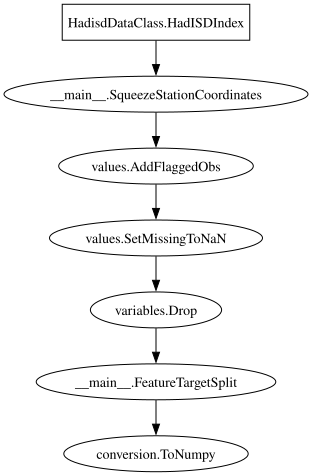

In [7]:
# Hadisd accepts "all" as an argument to get all stations.
# A single station can also be specified, e.g. "010010-99999".
# Or, a list of station IDs can be passed.

# TODO: Make numpy conversion step work. Add functionality for selecting rang, selecting nearest neigbours, etc
data_prep_pipe = petpipe.Pipeline(
    petdata.archive.hadisd(station = first_ten_stations), #, variables = ["total_cloud_cover", "temperatures", "flagged_obs"]), # Commented out variable selection whilst looking into bug in BaseTransforms
    SqueezeStationCoordinates(), # Squeeze coordinates to 1D if they are 2D: Remove redundant dimensions
    petdata.transforms.values.AddFlaggedObs(flagged_labels),
    petdata.transforms.values.SetMissingToNaN(varname_val_map),
    petdata.transforms.variables.Drop("flagged_obs"), # Drop the flagged_obs variable as it is not needed for ML an might even introduce bias
    FeatureTargetSplit(target_vars="quality_control_flags"), # Split dataset into features and target variable

    petpipe.operations.xarray.conversion.ToNumpy(), # Doesn't work for HadISD in current format. Must fix
    #petdata.transofmrs.derive.WetBulbTemp(), # Just an idea for now. Should probably be in a separate pipeline where heavier processing is done
)
data_prep_pipe

In [8]:
x, y = data_prep_pipe["1969-01-01T07"]
x

/Users/joelmiller/Projects/Python/PyEarthTools_Fork/PyEarthTools/packages/data/src/pyearthtools/data/indexes/indexes.py:492: IndexWarning: Could not find time in dataset to select on. Petdt('1969-01-01T07')
  warnings.warn(


array([[[        nan,         nan,         nan, ..., -1.3500e+01,
         -1.3500e+01, -1.3500e+01],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ..., -3.6000e+00,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ..., -1.1000e+01,
         -1.1400e+01, -1.1200e+01],
        [        nan,         nan,         nan, ..., -1.2200e+01,
         -1.2700e+01, -1.2600e+01],
        [        nan,         nan,         nan, ..., -8.1000e+00,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,  5.6000e+00,
          6.7000e+00,  5.9000e+00],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,  1.8000e+00,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,  

In [9]:
y

array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        ...,

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan

In [10]:
print (f"Shape of X: {x.shape}")
x

Shape of X: (22, 100, 473352)


array([[[        nan,         nan,         nan, ..., -1.3500e+01,
         -1.3500e+01, -1.3500e+01],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ..., -3.6000e+00,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ..., -1.1000e+01,
         -1.1400e+01, -1.1200e+01],
        [        nan,         nan,         nan, ..., -1.2200e+01,
         -1.2700e+01, -1.2600e+01],
        [        nan,         nan,         nan, ..., -8.1000e+00,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,  5.6000e+00,
          6.7000e+00,  5.9000e+00],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,  1.8000e+00,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,  

In [11]:
# Impute missing values in X
def median_impute_per_station_np(x):
    # x shape: (features, stations, time)
    x_imputed = x.copy()
    for i in range(x.shape[0]):  # for each feature
        for j in range(x.shape[1]):  # for each station
            arr = x[i, j, :]
            median = np.nanmedian(arr)
            arr_imputed = np.where(np.isnan(arr), median, arr)
            x_imputed[i, j, :] = arr_imputed
    return x_imputed

# Usage:
x_imputed = median_impute_per_station_np(x)

/var/folders/v1/7wypnx5x11qgv022zwx5p3g00000gn/T/ipykernel_56334/649222260.py:8: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(arr)


In [12]:
print(f"Shape of X after imputation: {x_imputed.shape}")
x_imputed

Shape of X after imputation: (22, 100, 473352)


array([[[-1.0000e+00, -1.0000e+00, -1.0000e+00, ..., -1.3500e+01,
         -1.3500e+01, -1.3500e+01],
        [ 5.0000e+00,  5.0000e+00,  5.0000e+00, ...,  5.0000e+00,
          5.0000e+00,  5.0000e+00],
        [-4.0000e+00, -4.0000e+00, -4.0000e+00, ..., -3.6000e+00,
         -4.0000e+00, -4.0000e+00],
        ...,
        [-3.0000e+00, -3.0000e+00, -3.0000e+00, ..., -1.1000e+01,
         -1.1400e+01, -1.1200e+01],
        [-4.0000e+00, -4.0000e+00, -4.0000e+00, ..., -1.2200e+01,
         -1.2700e+01, -1.2600e+01],
        [-9.0000e-01, -9.0000e-01, -9.0000e-01, ..., -8.1000e+00,
         -9.0000e-01, -9.0000e-01]],

       [[ 6.0000e+00,  6.0000e+00,  6.0000e+00, ...,  5.6000e+00,
          6.7000e+00,  5.9000e+00],
        [ 4.1000e+00,  4.1000e+00,  4.1000e+00, ...,  4.1000e+00,
          4.1000e+00,  4.1000e+00],
        [ 5.0000e+00,  5.0000e+00,  5.0000e+00, ...,  1.8000e+00,
          5.0000e+00,  5.0000e+00],
        ...,
        [ 3.0000e+00,  3.0000e+00,  3.0000e+00, ...,  

In [13]:
print(f"Shape of y: {y.shape}")
y

Shape of y: (1, 100, 473352, 71)


array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        ...,

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan

# Manipulate X and y to work with XGBoost
I would like to train a model that predicts the quality control flags for test 5 based on the other variables.<br>
First we need to extract our target data from the entire dataset of qualit

# Extracing Target Variable From y

We would like to train a model that predicts the quality control flags for test 5 based on all other variables.<br>
- First we need to extract our target data from the y variable, which is a DataArray with the quality control flags.<br>
- The target data is a 2D array with shape (stations, time) and contains the quality control flags for test 5.<br>

In [14]:
# Select test 5 of 71 from y, where y target data is: (1, 10, 473352, 71)
y_test_5 = y[0, :, :, 5]
print(f"Shape of y_test_5: {y_test_5.shape}")

Shape of y_test_5: (100, 473352)



**X has shape (22, 10, 473352):**

- 22 = features
- 10 = stations
- 473352 = time
But XGBoost expects X to be 2D: (n_samples, n_features)

We need each sample to be a (22,) feature vector, and want one sample for each (station, time) pair.

### Step 1 - Move features to the last axis, then flatten station and time


In [15]:
# Move features to last axis, then flatten station and time
x_transposed = np.transpose(x, (1, 2, 0))  # shape: (10, 473352, 22)
X_flat = x_transposed.reshape(-1, x.shape[0])  # shape: (10*473352, 22)
print(f"Shape of X after transposition: {x_transposed.shape}")
print(f"Shape of X after flattening: {X_flat.shape}")

Shape of X after transposition: (100, 473352, 22)
Shape of X after flattening: (47335200, 22)


### Step 2 - Reshape y to match X_flat

In [16]:
y_flat = y_test_5.reshape(-1)  # shape: (10*473352,)
print(f"Shape of y after flattening: {y_flat.shape}")

Shape of y after flattening: (47335200,)


### Step 3 - Filter Samples Where y is NaN

In [17]:
# Filter out samples where y is nan
mask = ~np.isnan(y_flat)
X_final = X_flat[mask]
y_final = y_flat[mask]

print(f"Shape of X_final: {X_final.shape}")
print(f"Shape of y_final: {y_final.shape}")
y_final

Shape of X_final: (20788945, 22)
Shape of y_final: (20788945,)


array([0., 0., 0., ..., 0., 0., 0.])

In [18]:
# Print all unique values in y_test_5, including NaN
unique_values = np.unique(y_final)
print(f"Unique values in y_test_5: {unique_values}")

# Print number of values where y is 1
num_ones = np.sum(y_final == 1)
print(f"Number of values where y is 1: {num_ones}")

Unique values in y_test_5: [0. 1.]
Number of values where y is 1: 1579


In [19]:
X_flat = x_imputed.reshape(x_imputed.shape[0], -1).T  # shape: (n_samples, n_features)
y_flat = y_test_5.flatten()  # shape: (n_samples,)

# Filter out samples where y is nan
mask = ~np.isnan(y_flat)
X_final = X_flat[mask]
y_final = y_flat[mask]

In [20]:
print(f"Shape of X_final: {X_final.shape}")
print(f"Shape of y_final: {y_final.shape}")

Shape of X_final: (20788945, 22)
Shape of y_final: (20788945,)


# Train a Model

In [21]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Split data (stratify to preserve class imbalance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (len(y_train) - np.sum(y_train)) / np.sum(y_train)

# Create and fit model
bst = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)
bst.fit(X_train, y_train)

# Predict on test set
y_pred = bst.predict(X_test)

/Users/joelmiller/miniconda3/envs/pet_tutorial/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:34:53] WARNING: /var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_48ydvcv9e5/croot/xgboost-split_1748329884729/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99   4157473
         1.0       0.00      0.91      0.01       316

    accuracy                           0.98   4157789
   macro avg       0.50      0.95      0.50   4157789
weighted avg       1.00      0.98      0.99   4157789



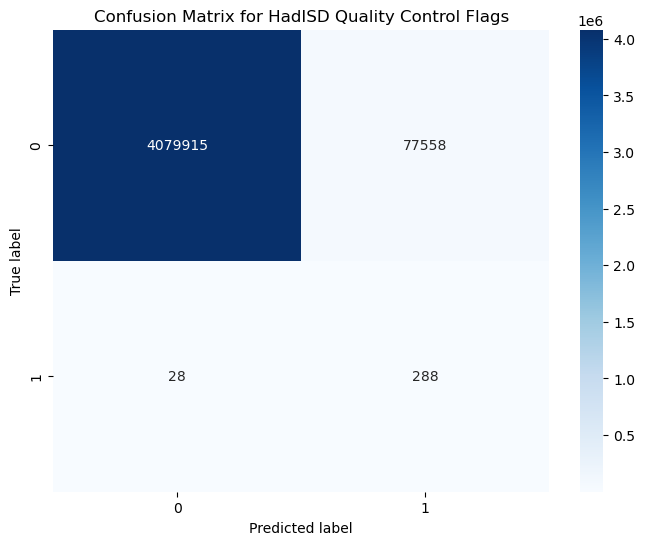

In [22]:
# compare predictions with true labels
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
#print(confusion_matrix(y_test, y_pred)) 

# Plot nice confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, classes=['0', '1'], title='Confusion Matrix for HadISD Quality Control Flags')

In [ ]:
from xgboost import XGBClassifier
# read data
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(data['data'], data['target'], test_size=.2)
# create model instance
bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
# fit model
bst.fit(X_train, y_train)
# make predictions
preds = bst.predict(X_test)

# Quality Control Exploration

In [ ]:
qc = y["quality_control_flags"].values
# Convert to pandas DataFrame for easier manipulation
import pandas as pd
qc_df = pd.DataFrame(qc, columns=y["quality_control_flags"].dims[1:], index=x.time.values)
# Display the first few rows of the DataFrame
qc_df.head()

In [ ]:
print("Unique QC flag values:", np.unique(qc[~np.isnan(qc)]))
print("QC flag shape:", qc.shape)

In [ ]:
for i in range(qc.shape[2]):  # for each test
    unique_vals = np.unique(qc[:, :, i][~np.isnan(qc[:, :, i])])
    print(f"Test {i}: unique QC flag values: {unique_vals}")

In [ ]:
# Sum of flags per test (across all stations and times)
qc_sum_per_test = np.nansum(qc, axis=(0, 1))
print("QC fails per test:", qc_sum_per_test)

# Sum per station
qc_sum_per_station = np.nansum(qc, axis=(1, 2))
print("QC fails per station:", qc_sum_per_station)

In [ ]:
for i in range(0, 71):
    failed = np.where(qc[:, :, i] == 1)
    print(f"Stations with fails for test {i}:", failed[0])
    print(f"Times with fails for test {i}:", failed[1])


In [ ]:
# Stations with fails for test 12: [0]
# Times with fails for test 12: [826]

# for qc, test 12, time 826, station 0, print the value of the test
print("QC value for test 12, time 826, station 0:", qc[0, 826, 12])

# XGBoost Example

In [ ]:
# First take quality control flags and binarise them to 0/1
# - 0 values stay 0
# - 1 values stay 1
# - 2 values become 1
# - -1 values are forgotten about

# Start by training a model that predicts for test 5 (DGP- Gap - Dew Point) since this already has a binary output
# - In future we can train a model that predicts for all tests in onw go, but for now let's keep it simple

In [ ]:
qc_test_5= y_imputed["quality_control_flags"].values[:,:, 5] # shape: (station, time)
failed_indices = np.where(qc_test_5 == 1)
type_qc_test_5 = type(qc_test_5)  # Convert to int for binary representation
shape_qc_test_5 = qc_test_5.shape
sum_qc_test_5 = np.sum(qc_test_5 == 1)  # Count of 1s in the array

print(f"Type of qc_test_5 is: {type_qc_test_5}")
print(f"Shape of qc_test_5 is: {shape_qc_test_5}")
print(f"Location of 1 values in qc_test_5: {failed_indices}")
print(f"Number of failed tests in qc_test_5: {sum_qc_test_5}")

In [ ]:
target = qc_test_5.copy()
print(f"Target shape: {target.shape}")

In [ ]:
# We now have our target data ready, with shape (station, time)
# Next, we need to prepare our features (X) from the input data (x_imputed)
# For simplicity, let's use all variables in x_imputed as features
feature_vars = list(x_imputed.data_vars)
feature_vars

# View Flagged Observations & Imputed Values

In [ ]:
#view flagged obs for station 0 and time 0 (These are imputed values, otherwise they would be NaN and give no clues)
station_index = 4
time_index = 100000
flagged_obs = y_imputed["flagged_obs"].values[station_index, time_index]
print(f"Flagged observations for station {station_index} at time {time_index}: {flagged_obs}")

In [ ]:
# view qc data for station 0 and time 0
station_index = 0
time_index = 0 
qc_data = x["quality_control_flags"].values[station_index, time_index]
print (f"test for station {station_index} at time {time_index}: {qc_data}")


In [ ]:
qc = x["quality_control_flags"].values
# Find indices where qc is not 0 and not NaN
indices = np.where((qc != 0) & ~np.isnan(qc))

print(f"Number of non-zero quality control flags: {len(indices[0])}")
print("Indices (station, time, test):")
for idx in zip(*indices):
    print(idx)


In [ ]:
print(x["quality_control_flags"].coords["test"].values)

In [ ]:
print(y["flagged_obs"].coords["flagged"].values)

## Impute Median Values to get clearer picture of data structure where NaNs present

Everything here is for my understanding

In [ ]:
ds = x

def median_impute_per_station(ds):
    ds_imputed = ds.copy()
    for var in ds.data_vars:
        arr = ds[var].values  # shape: (station, time)
        # Compute median for each station (axis=1 is time)
        medians = np.nanmedian(arr, axis=1)
        # Broadcast medians to the shape of arr
        arr_imputed = np.where(np.isnan(arr), medians[:, None], arr)
        ds_imputed[var].values = arr_imputed
    return ds_imputed

# Usage:
x_imputed = median_impute_per_station(x)

In [ ]:
ds = y

def median_impute_per_station(ds):
    ds_imputed = ds.copy()
    for var in ds.data_vars:
        arr = ds[var].values  # shape: (station, time)
        # Compute median for each station (axis=1 is time)
        medians = np.nanmedian(arr, axis=1)
        # Broadcast medians to the shape of arr
        arr_imputed = np.where(np.isnan(arr), medians[:, None], arr)
        ds_imputed[var].values = arr_imputed
    return ds_imputed

# Usage:
y_imputed = median_impute_per_station(y)

In [ ]:
x_imputed

In [ ]:
y_imputed

# Messing With XGBoost

In [ ]:
from xgboost import XGBClassifier
# read data
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(x['data'], y['target'], test_size=.2)
X_train

In [ ]:
# create model instance
bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
# fit model
bst.fit(X_train, y_train)
# make predictions
preds = bst.predict(X_test)

In [ ]:
# Set up the caching mechanism to store processed data in the specified folder with .npy extension
cache_folder = Path('/Users/joelmiller/Desktop/cache')
cache_folder.mkdir(parents=True, exist_ok=True)

caching_step = petpipe.modifications.Cache(
    cache_folder, 
    pattern_kwargs={'extension': 'nc'},
    # cache_validity='delete'
)

In [ ]:
# Add the caching step to the pipeline
data_preparation_normed = petpipe.Pipeline(
    data_prep_pipe,
    caching_step
)

In [ ]:
x, y = data_preparation_normed["1970-01-01T06"]
x

In [ ]:
# open single netcdf file with xarray
import xarray as xr
ds = xr.open_dataset("/Users/joelmiller/Desktop/cache/1970/01/01/19700101T0600.nc/0.nc")
ds

In [ ]:
for coord in ["latitude", "longitude", "elevation"]:
    if coord in ds:
        ds = ds.set_coords(coord)
ds

In [ ]:
for coord in ["latitude", "longitude", "elevation"]:
    if coord in ds.coords and "coordinate_length" in ds[coord].dims:
        ds[coord] = ds[coord].squeeze("coordinate_length")

ds

In [ ]:
ds_numpy= ds.pipe(petpipe.operations.xarray.conversion.ToNumpy())
ds_numpy

In [ ]:
for coord in ["latitude", "longitude", "elevation"]:
    if coord in ds:
        ds = ds.set_coords(coord)

ds

In [ ]:
import pyearthtools.data as petdata
# select only total_cloud_cover
ds_all_tcc = ds.pipe(petdata.transforms.variables.Select("total_cloud_cover", "dewpoints", "temperatures"))
ds_all_tcc

In [ ]:
print(ds_all_tcc)
for name, coord in ds_all_tcc.coords.items():
    print(f"{name}: {coord.shape}")
for name, var in ds_all_tcc.data_vars.items():
    print(f"{name}: {var.shape}")

In [ ]:
ds_numpy= ds_all_tcc.pipe(petpipe.operations.xarray.conversion.ToNumpy())
ds_numpy

In [ ]:
# Show the lat and lon coordinatesfor the first station
print(f"Latitude: {ds.latitude.values[1]}")
print(f"Longitude: {ds.longitude.values[1]}")




# Notes:
- Dropping variables results in coordinates being dropped, which is not what we want.
- Calculating wetbulb temps for just 10 stations takes a very long time; therefore, 
  I wonder if it is best suited to a separate pre-processing pipeline to get the data into a more suitable format ready for manipulations to be done.
- Don't know what combination of stations you want when selecting nearest neighbours, so want to cahce on a per-station basis. This might be differnt with zarr.

TODO:
- Change preprocessing so that coordinates are not dropped when dropping or selecting variables.

In some cases you will get the following error when passing a date time to a pipeline object: `IndexWarning: Could not find time in dataset to select on. Petdt('1931-01-01T07')`<br>

This indicates that data for the datetime you chose does not exist. In this case PET will load all data from your station selection.

In [ ]:
# show total_cloud_cover from ds
tcc = ds["total_cloud_cover"]
tcc

# For specific Stations

In [ ]:
from pyearthtools.tutorial.HadisdDataClass import HadISDIndex
from pathlib import Path
hadisd = HadISDIndex(["010014-99999", "010010-99999", "010030-99999"], variables=["total_cloud_cover", "temperatures", "dewpoints", "flagged_obs"])
paths = hadisd.filesystem()
paths


In [ ]:
# Check waht class attribute is set for the HadISDIndex object
print(hadisd.station)
print(hadisd.variables)

In [ ]:
file_paths = list(paths.values())
file_paths

In [ ]:
ds = hadisd.load(file_paths)
ds

In [ ]:
lat_values = ds["latitude"].values
lon_values = ds["longitude"].values
elev_values = ds["elevation"].values
lat_values

import numpy as np

# Ensure 1D arrays for each coordinate
lat_values = np.asarray(ds["latitude"].values).reshape(-1)
lon_values = np.asarray(ds["longitude"].values).reshape(-1)
elev_values = np.asarray(ds["elevation"].values).reshape(-1)

In [ ]:
ds = ds.assign_coords(
    latitude=("station", lat_values),
    longitude=("station", lon_values),
    elevation=("station", elev_values),
)

In [ ]:
# set all missing values to NaN
ds_3_nan = ds.pipe(petdata.transforms.values.SetMissingToNaN(varname_val_map))
ds_3_nan

In [ ]:
# View all lat/lon values
ds_3_nan["latitude"].values, ds_3_nan["longitude"].values

In [ ]:
import matplotlib.pyplot as plt
flagged_counts = np.sum(~np.isnan(ds['flagged_obs'].values), axis=(1,2))  # sum over time and flagged
plt.bar(range(ds.dims['station']), flagged_counts)
plt.xlabel('Station')
plt.ylabel('Number of flagged obs')
plt.show()

In [ ]:
import pandas as pd
time = pd.to_datetime(ds['time'].values)
flag = ~np.isnan(ds['flagged_obs'].isel(station=0, flagged=0).values)
flag_series = pd.Series(flag, index=time)
flag_counts = flag_series.resample('y').sum()
flag_counts.plot()
plt.ylabel('Flagged obs per year')
plt.show()

# For all stations

In [ ]:
hadisd = HadISDIndex("all")

all_station_ids = hadisd.get_all_station_ids(Path("/Users/joelmiller/Projects/data/hadisd"))
print(all_station_ids[:10])
print(len(all_station_ids))


In [ ]:
hadisd = HadISDIndex(all_station_ids)
paths = hadisd.filesystem() 
paths = list(paths.values())

In [ ]:
ds_all = hadisd.load(paths)
ds_all

In [ ]:
import pyearthtools.data as petdata
# select only total_cloud_cover
ds_all_tcc = ds_all.pipe(petdata.transforms.variables.Select("total_cloud_cover"))
ds_all_tcc


In [ ]:
# Manuall apply the transform
varname_val_map = {
        "total_cloud_cover": -999., 
        "low_cloud_cover": -999., 
        "mid_cloud_cover": -999.,
        "high_cloud_cover": -999.
    }

ds_all_tcc_nan = ds_all.pipe(petdata.transforms.values.SetMissingToNaN(varname_val_map))
ds_all_tcc_nan

In [ ]:
tcc = ds_all["total_cloud_cover"]
tcc

# Stuff in this section is not used in the tutorial, but is useful for testing and exploration

In [ ]:

# I think used for preprocessing to zarr?
date_range=(datetime.datetime(1986,11,20,12,0), datetime.datetime(1986,11,21,0,0))

In [ ]:
varname_val_map = {
        "total_cloud_cover": -999., 
        "low_cloud_cover": -999., 
        "mid_cloud_cover": -999.,
        "high_cloud_cover": -999.
    }

# Probably sensible to accetp a list since some variables might have multiple values
# This would look like:
# varname_val_map = {
#         "total_cloud_cover": [-888., -999.],
#         "low_cloud_cover": [-888., -999.],
#         "mid_cloud_cover": [-999.],
#         "high_cloud_cover": [-999.]
#     }

In [ ]:
# train/validation/test split dates
train_start = "1970-01-01T00"
train_end = "2022-12-31T23"

In [ ]:
data_prep_pipe = petpipe.Pipeline(
    # petdata.archive.hadisd(("010010-99999"), variables = ["total_cloud_cover", "temperatures", "flagged_obs"]),
    # petdata.archive.hadisd(station = ["010014-99999"], variables = ["total_cloud_cover", "temperatures", "flagged_obs"]),
    
    # Current options for indexing
    #petdata.archive.hadisd(["010014-99999", "010010-99999", "010030-99999"]),    
    petdata.archive.hadisd("010010-99999", variables=["total_cloud_cover", "temperatures", "flagged_obs"]),

    petdata.transforms.values.AddFlaggedObs(flagged_labels),
    petdata.transforms.values.SetMissingToNaN(varname_val_map),
    
    # Possible ways of indexing in the future:
    # petdata.archive.hadisd(country_code = "24", station_id = "010010", nearest_neighbors = 12, lon= 0.0, lat = 0.0), # Geospatial fence 
    # petdata.archive.hadisd("010014-99999"), # Geospatial fence
)
data_prep_pipe

# Don't know what combination of stations you want when selecting nearest neighbours, so want to cahce on a per-station basis

In [ ]:
# Show index and variable where value = -999
# Did this becasue some missing values were not converted to NaN, but it was because I added flagged_obs variable after the SetMissingToNaN operation.
for var in x.data_vars:
    if np.any(x[var].values == -999):
        print(f"Variable: {var}, Indexes with -999: {np.where(x[var].values == -999)}")

# Use the section below to build tests to check that all pipeline steps are working as expected

## Test SetMissingToNaN

In [ ]:
import xarray as xr
from pyearthtools.data.transforms.values import SetMissingToNaN
import numpy as np

def test_set_missing_to_nan():
    data = xr.Dataset({
        "total_cloud_cover": ("time", [0, -999, 50]),
        "low_cloud_cover": ("time", [10, -999, 20]),
    })

    varname_val_map = {
        "total_cloud_cover": -999.0,
        "low_cloud_cover": -999.0,
    }

    transform = SetMissingToNaN(varname_val_map)
    transformed_data = transform.apply(data)

    if np.isnan(transformed_data["total_cloud_cover"].data[1]):
        print("Total cloud cover at index 1 is NaN")
    else:
        print("Total cloud cover at index 1 is not NaN")
    
    if np.isnan(transformed_data["low_cloud_cover"].data[1]):
        print("Low cloud cover at index 1 is NaN")
    
    if transformed_data["total_cloud_cover"].data[2] == 50:
        print("Total cloud cover at index 2 is 50")

In [ ]:
test_set_missing_to_nan()

## Test AddFlaggedObs

In [ ]:
import xarray as xr
import numpy as np
from pyearthtools.data.transforms.values import AddFlaggedObs

def test_add_flagged_obs():
    # Mock dataset with flagged observations
    data = xr.Dataset(
        {
            "temperatures": (("time",), [np.nan, 15.0, np.nan]),
            "dewpoints": (("time",), [np.nan, 10.0, np.nan]),
            "flagged_obs": (
                ("time", "flagged"),
                [
                    [20.0, np.nan],  # Flagged data for time=0
                    [np.nan, np.nan],  # No flagged data for time=1
                    [25.0, 12.0],  # Flagged data for time=2
                ],
            ),
        },
        coords={
            "time": [0, 1, 2],
            "flagged": [0, 1],  # Indices for flagged variables
        },
    )

    # Add flagged_value attribute to variables
    data["temperatures"].attrs["flagged_value"] = -999.0
    data["dewpoints"].attrs["flagged_value"] = -999.0

    # Define flagged labels corresponding to the flagged dimension
    flagged_labels = ["temperatures", "dewpoints"]

    # Apply the AddFlaggedObs transform
    transform = AddFlaggedObs(flagged_labels)
    transformed_data = transform.apply(data)

    # Assert that flagged data has been restored
    assert np.allclose(
        transformed_data["temperatures"].data, [20.0, 15.0, 25.0], equal_nan=True
    )
    assert np.allclose(
        transformed_data["dewpoints"].data, [np.nan, 10.0, 12.0], equal_nan=True
    )

    print("Test passed: Flagged observations were correctly restored.")

# Run the test
test_add_flagged_obs()